## Import Library & Setup Environment

In [1]:
# Cell 1: Import library untuk Deep Learning & Fine-Tuning
import pandas as pd
import torch
import matplotlib.pyplot as plt
import os
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer

# Membuat folder untuk menyimpan model hasil training
os.makedirs('../models/lora_cs_model', exist_ok=True)
os.makedirs('../grafik_laporan', exist_ok=True)

print("Library berhasil di-load! PyTorch version:", torch.__version__)

c:\Users\acer\anaconda3\envs\cs_ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Library berhasil di-load! PyTorch version: 2.5.1+cu121


## Memuat Dataset Hasil Preprocessing

In [3]:
# Cell 2: Load Dataset Siap Latih
print("=== Memuat Dataset ===")
data_path = '../data/processed/finetuning_dataset.csv'
df_train = pd.read_csv(data_path)

# Mengonversi Pandas DataFrame menjadi HuggingFace Dataset
dataset = Dataset.from_pandas(df_train)

print(f"Total data siap latih: {len(dataset)} baris")
print("Contoh sekilas:")
# PERBAIKAN DI SINI: Menggunakan 'text' sesuai output Notebook 01
print(dataset[0]['text'][:100] + "...")

=== Memuat Dataset ===
Total data siap latih: 2500 baris
Contoh sekilas:
<|system|>
Anda adalah agen Customer Service AI yang empatik, sopan, dan profesional. Selalu berikan...


## Inisialisasi Model & Tokenizer (Kuantisasi 4-bit)

In [4]:
# Cell 3: Load Model Dasar (TinyLlama)
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
print(f"=== Mengunduh & Memuat Model: {model_id} ===")

# Inisialisasi Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Konfigurasi Kuantisasi 4-bit (Meringankan beban memori)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

# Load Model
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto" # Otomatis mendeteksi GPU/CPU
)

model = prepare_model_for_kbit_training(model)
print("Model berhasil dimuat dalam format 4-bit!")

=== Mengunduh & Memuat Model: TinyLlama/TinyLlama-1.1B-Chat-v1.0 ===


Loading weights: 100%|██████████| 201/201 [00:01<00:00, 120.06it/s]


Model berhasil dimuat dalam format 4-bit!


## Konfigurasi Arsitektur LoRA (Hyperparameter Tuning)

In [5]:
# Cell 4: Setting LoRA (Low-Rank Adaptation)
print("=== Konfigurasi LoRA ===")

# Hyperparameter Tuning untuk Arsitektur
peft_config = LoraConfig(
    r=8,                     # Rank dimensi (semakin kecil semakin ringan)
    lora_alpha=16,           # Skala penyesuaian bobot
    target_modules=["q_proj", "v_proj"], # Bagian 'otak' model yang akan dilatih
    lora_dropout=0.05,       # Mencegah overfitting (Dropout)
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, peft_config)

# Menampilkan jumlah parameter yang dilatih (Biasanya < 1% dari total parameter model asli)
model.print_trainable_parameters()

=== Konfigurasi LoRA ===
trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


## Menjalankan Proses Fine-Tuning

In [ ]:
# Cell 5: Setup Trainer & Mulai Training
print("=== Memulai Proses Fine-Tuning ===")
import torch
from trl import SFTTrainer, SFTConfig

is_bf16_supported = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

training_args = SFTConfig(
    output_dir="../models/checkpoints",
    per_device_train_batch_size=2,    
    gradient_accumulation_steps=4,
    learning_rate=2e-4,               
    logging_steps=5,                  
    max_steps=60,                     
    save_steps=60,
    optim="paged_adamw_8bit",         
    lr_scheduler_type="linear",
    
    fp16=not is_bf16_supported, 
    bf16=is_bf16_supported,     
    
    dataset_text_field="text",   
    max_length=512,  
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    processing_class=tokenizer,  
    args=training_args,          
)

# EKSEKUSI TRAINING!
trainer.train()
print("Training Selesai!")

=== Memulai Proses Fine-Tuning ===


Truncating train dataset: 100%|██████████| 2500/2500 [00:00<00:00, 312448.15 examples/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
5,1.943498
10,1.967199
15,1.697485
20,1.504356
25,1.295370
30,1.230474
35,1.137669
40,1.127667
45,1.068862
50,1.058772


Training Selesai!


## Evaluasi Model (Visualisasi Loss) & Simpan Model

=== Evaluasi & Ekspor Model ===


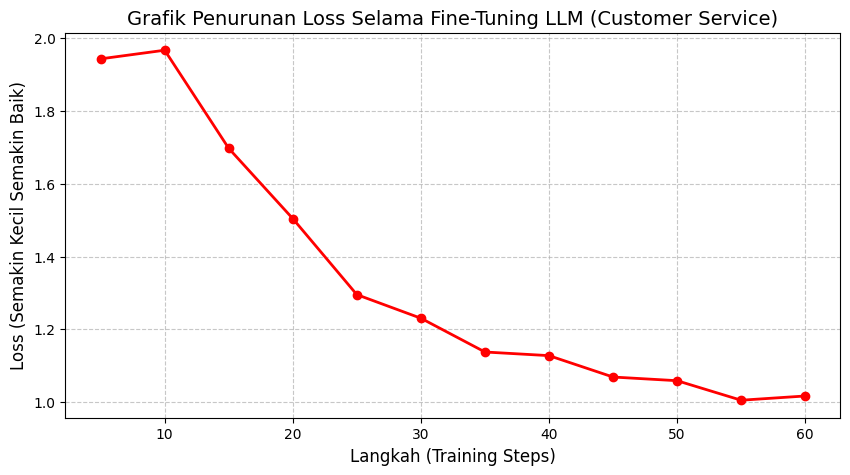

🎉 Sukses! Model Fine-Tuned berhasil disimpan di folder: ../models/lora_cs_model


In [ ]:
# Cell 6: Evaluasi Visual & Ekspor Model
print("=== Evaluasi & Ekspor Model ===")

# 1. Mengambil data log loss selama proses belajar
log_history = trainer.state.log_history
losses = [log['loss'] for log in log_history if 'loss' in log]
steps = [log['step'] for log in log_history if 'loss' in log]

# 2. Membuat Grafik Penurunan Loss
plt.figure(figsize=(10, 5))
plt.plot(steps, losses, marker='o', color='red', linestyle='-', linewidth=2)
plt.title('Grafik Penurunan Loss Selama Fine-Tuning LLM (Customer Service)', fontsize=14)
plt.xlabel('Langkah (Training Steps)', fontsize=12)
plt.ylabel('Loss (Semakin Kecil Semakin Baik)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Menampilkan grafik
plt.show()

# 3. Menyimpan model akhir (Otak tambahan / Adapter LoRA)
output_model_dir = "../models/lora_cs_model"
trainer.model.save_pretrained(output_model_dir)
tokenizer.save_pretrained(output_model_dir)

print(f"🎉 Sukses! Model Fine-Tuned berhasil disimpan di folder: {output_model_dir}")